# 08 - Final Strategy Comparison and Benchmark Analysis

## Purpose of this notebook

In this notebook, I bring together the strongest strategies from the project and compare them against trusted public benchmarks.

The goal is to determine:
- which internal strategy is the strongest overall
- whether the extra complexity of ETF-level tuning is justified
- how the project compares to simple market benchmarks
- how the project compares to more professional systematic portfolio baselines

## Strategy finalists

The main internal finalists are:
- Shared 180-day tactical ETF model
- Best static ETF-level model

I may also keep a few other shared-baseline models for context:
- Shared 120-day model
- Shared 252-day model

## External benchmarks

The external benchmarks used in this notebook are:
- SPY buy-and-hold
- 60/40 portfolio
- Equal-weight ETF basket
- RPAR
- DBMF
- KMLM

## Main research question

Among the strategies I built, which one is best once I compare:
- return
- volatility
- Sharpe
- drawdown
- Calmar
- rolling behavior
- benchmark-relative performance

This notebook is meant to be the final decision notebook before building the dashboard/app layer.

## 2. Import libraries

In this section, I import the libraries needed for:
- loading saved project outputs
- downloading benchmark ETF data
- computing performance metrics
- creating comparison charts

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from pathlib import Path

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

/Users/nicholasturangan/Desktop/quant/quant-portfolio-project/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 3. Load internal strategy results

In this section, I load the strongest strategy return series from earlier notebooks.

## What this section is doing

I load:
- shared baseline return series
- best static ETF-level return series
- monthly returns for building simple internal benchmarks

These files are the core internal strategy outputs from the previous stages of the project.

In [3]:
DATA_DIR = Path("../data")
PROCESSED_DIR = DATA_DIR / "processed"

shared_baseline_returns = pd.read_csv(PROCESSED_DIR / "strategy_returns_shared_baseline.csv", index_col=0, parse_dates=True)
best_etf_returns = pd.read_csv(PROCESSED_DIR / "best_etf_level_returns.csv", index_col=0, parse_dates=True)
monthly_returns = pd.read_csv(PROCESSED_DIR / "monthly_returns.csv", index_col=0, parse_dates=True)

print("Shared baseline returns shape:", shared_baseline_returns.shape)
print("Best ETF-level returns shape:", best_etf_returns.shape)
print("Monthly returns shape:", monthly_returns.shape)

Shared baseline returns shape: (242, 4)
Best ETF-level returns shape: (242, 1)
Monthly returns shape: (253, 8)


## 4. Define internal finalists

In this section, I define the internal strategies that will be compared in the final evaluation.

## Why this matters

The project tested many variants, but I only want to carry forward the most meaningful finalists.

In [4]:
internal_strategies = pd.DataFrame(index=shared_baseline_returns.index)

internal_strategies["Shared_120d"] = shared_baseline_returns["Strategy_120d"]
internal_strategies["Shared_180d"] = shared_baseline_returns["Strategy_180d"]
internal_strategies["Shared_252d"] = shared_baseline_returns["Strategy_252d"]

best_etf_col = best_etf_returns.columns[0]
internal_strategies["Best_Static_ETF_Level"] = best_etf_returns[best_etf_col]

display(internal_strategies.head())

,Shared_120d,Shared_180d,Shared_252d,Best_Static_ETF_Level
2006-01-31,NaN,NaN,NaN,NaN
2006-02-28,-0.024799,-0.024799,-0.024799,-0.024799
2006-03-31,0.029098,0.029098,0.029098,0.029098
2006-04-28,0.095202,0.095202,0.095202,0.095202
2006-05-31,-0.063030,-0.063030,-0.063030,-0.063030


## 5. Build simple internal benchmarks

In this section, I build simple benchmark portfolios from the ETF universe.

## What this section is doing

I create:
- SPY buy-and-hold
- 60/40 portfolio using SPY and IEF
- equal-weight ETF basket

These are useful baseline comparisons that are easy to understand.

In [5]:
simple_benchmarks = pd.DataFrame(index=monthly_returns.index)

simple_benchmarks["SPY_BuyHold"] = monthly_returns["SPY"]
simple_benchmarks["Portfolio_60_40"] = 0.60 * monthly_returns["SPY"] + 0.40 * monthly_returns["IEF"]
simple_benchmarks["EqualWeight_ETFs"] = monthly_returns.mean(axis=1)

display(simple_benchmarks.head())

,SPY_BuyHold,Portfolio_60_40,EqualWeight_ETFs
Date,,,
2005-02-28,0.020904,0.007068,0.021226
2005-03-31,-0.018293,-0.012589,-0.024292
2005-04-29,-0.018736,-0.001175,-0.008905
2005-05-31,0.032225,0.026688,0.027376
2005-06-30,0.001515,0.002823,0.016557


## 6. Download professional benchmark ETF data

In this section, I download additional public benchmark ETFs that represent more professional systematic portfolio approaches.

## Benchmarks used

- RPAR: risk parity style benchmark
- DBMF: managed futures style benchmark
- KMLM: trend-following / managed futures style benchmark

## Why this matters

These benchmarks provide a more realistic comparison against public investable portfolios that resemble professional systematic strategies.

In [6]:
BENCHMARK_TICKERS = ["RPAR", "DBMF", "KMLM"]

benchmark_prices = yf.download(
    BENCHMARK_TICKERS,
    start=monthly_returns.index.min().strftime("%Y-%m-%d"),
    end=None,
    auto_adjust=False,
    progress=False
)

benchmark_adj_close = benchmark_prices["Adj Close"].sort_index().ffill().dropna()
benchmark_monthly_prices = benchmark_adj_close.resample("BM").last()

if len(benchmark_monthly_prices) > 0 and benchmark_adj_close.index.max().date() < benchmark_monthly_prices.index.max().date():
    benchmark_monthly_prices = benchmark_monthly_prices.iloc[:-1]

professional_benchmarks = benchmark_monthly_prices.pct_change().dropna()

display(professional_benchmarks.head())

/var/folders/sx/02p4fzbd32gghvv7j9kwgb5m0000gn/T/ipykernel_5064/2272398925.py:12: FutureWarning: 'BM' is deprecated and will be removed in a future version, please use 'BME' instead.
  benchmark_monthly_prices = benchmark_adj_close.resample("BM").last()


Ticker,DBMF,KMLM,RPAR
Date,,,
2021-01-29,-0.001174,0.005785,-0.012185
2021-02-26,0.044418,0.058123,-0.018290
2021-03-31,0.029178,-0.019329,-0.014041
2021-04-30,0.022447,0.060650,0.028609
2021-05-31,0.028904,0.000102,0.029739


## 7. Align all strategies and benchmarks

In this section, I combine all return series into one aligned comparison table.

## Why this matters

All cumulative plots and performance metrics need to be computed on a common index.

In [7]:
all_returns = pd.concat(
    [
        internal_strategies,
        simple_benchmarks,
        professional_benchmarks,
    ],
    axis=1
).dropna()

print("Combined comparison table shape:", all_returns.shape)
display(all_returns.head())

Combined comparison table shape: (62, 10)


,Shared_120d,Shared_180d,Shared_252d,Best_Static_ETF_Level,SPY_BuyHold,Portfolio_60_40,EqualWeight_ETFs,DBMF,KMLM,RPAR
2021-01-29,0.025181,0.038931,-0.016938,0.025181,-0.010190,-0.010482,-0.001835,-0.001174,0.005785,-0.012185
2021-02-26,0.033076,0.033076,0.028736,0.028736,0.027806,0.007230,-0.003097,0.044418,0.058123,-0.018290
2021-03-31,0.002783,0.002783,0.015693,0.015693,0.045399,0.017697,0.000831,0.029178,-0.019329,-0.014041
2021-04-30,0.014707,0.040456,0.039781,0.035169,0.052910,0.035751,0.030251,0.022447,0.060650,0.028609
2021-05-31,0.005258,0.005258,-0.005214,0.002971,0.006566,0.005639,0.016204,0.028904,0.000102,0.029739


## 8. Define performance metric functions

In this section, I define helper functions for:
- CAGR
- annualized volatility
- Sharpe
- max drawdown
- Calmar
- rolling metrics

These will be used to compare the finalists against the benchmarks.

In [8]:
def compute_metrics(return_series):
    return_series = return_series.dropna()
    if len(return_series) == 0:
        return {}

    cumulative = (1 + return_series).cumprod()
    total_months = len(return_series)

    cagr = cumulative.iloc[-1] ** (12 / total_months) - 1
    ann_vol = return_series.std() * np.sqrt(12)
    sharpe = cagr / ann_vol if ann_vol != 0 else np.nan

    running_max = cumulative.cummax()
    drawdown = cumulative / running_max - 1
    max_dd = drawdown.min()

    calmar = cagr / abs(max_dd) if max_dd != 0 else np.nan

    return {
        "CAGR": cagr,
        "Annual Vol": ann_vol,
        "Sharpe": sharpe,
        "Max Drawdown": max_dd,
        "Calmar": calmar,
    }


def rolling_cagr(return_series, window=36):
    cumulative = (1 + return_series).rolling(window).apply(np.prod, raw=True)
    return cumulative ** (12 / window) - 1


def rolling_vol(return_series, window=36):
    return return_series.rolling(window).std() * np.sqrt(12)


def rolling_sharpe(return_series, window=36):
    rcagr = rolling_cagr(return_series, window)
    rvol = rolling_vol(return_series, window)
    return rcagr / rvol

## 9. Full-sample metrics table

In this section, I compute the main full-sample metrics for all strategies and benchmarks.

## Why this matters

This is the first clean snapshot of how our finalists compare to public baselines.

In [10]:
metrics_full = pd.DataFrame(
    {col: compute_metrics(all_returns[col]) for col in all_returns.columns}
).T

metrics_full.sort_values("Sharpe", ascending=False)

,CAGR,Annual Vol,Sharpe,Max Drawdown,Calmar
Shared_252d,0.151873,0.131968,1.150828,-0.225921,0.672238
Shared_120d,0.142022,0.127875,1.110625,-0.244820,0.580107
Shared_180d,0.123895,0.120031,1.032194,-0.238701,0.519038
Best_Static_ETF_Level,0.122227,0.126248,0.968148,-0.227819,0.536510
SPY_BuyHold,0.139733,0.149153,0.936839,-0.239272,0.583992
DBMF,0.106964,0.120924,0.884556,-0.172985,0.618344
Portfolio_60_40,0.078093,0.108559,0.719360,-0.205075,0.380804
EqualWeight_ETFs,0.083169,0.118623,0.701123,-0.239394,0.347417
KMLM,0.043770,0.127912,0.342184,-0.259263,0.168823
RPAR,0.026870,0.136449,0.196921,-0.285808,0.094013


## 10. Ranking table for internal finalists

In this section, I compare only the internal strategy finalists using the agreed ranking logic.

## Why this matters

This helps identify which internal strategy should be:
- the main strategy in the app
- the advanced strategy in the app

In [11]:
finalist_names = ["Shared_120d", "Shared_180d", "Shared_252d", "Best_Static_ETF_Level"]
finalist_metrics = metrics_full.loc[finalist_names].copy()

finalist_metrics.sort_values(
    by=["Sharpe", "Max Drawdown", "CAGR", "Calmar"],
    ascending=[False, False, False, False]
)

,CAGR,Annual Vol,Sharpe,Max Drawdown,Calmar
Shared_252d,0.151873,0.131968,1.150828,-0.225921,0.672238
Shared_120d,0.142022,0.127875,1.110625,-0.244820,0.580107
Shared_180d,0.123895,0.120031,1.032194,-0.238701,0.519038
Best_Static_ETF_Level,0.122227,0.126248,0.968148,-0.227819,0.536510


## 11. Cumulative growth comparison

In this section, I compare cumulative growth across all internal strategies and benchmarks.

## Why this matters

This gives a visual comparison of long-run behavior and helps identify which strategies compounded the best.

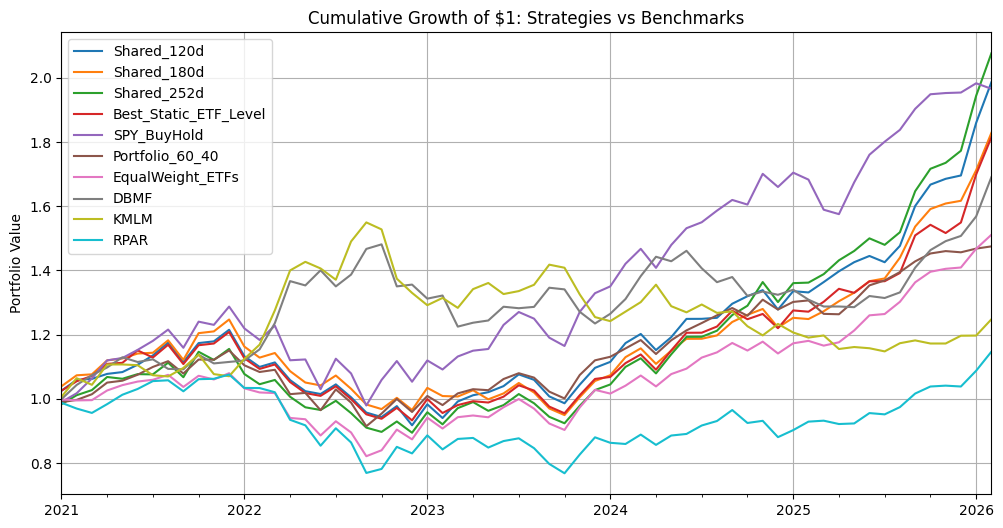

In [12]:
cumulative = (1 + all_returns).cumprod()

cumulative.plot(title="Cumulative Growth of $1: Strategies vs Benchmarks")
plt.ylabel("Portfolio Value")
plt.show()

## 12. Drawdown comparison

In this section, I compare drawdowns across the strategies and benchmarks.

## Why this matters

Two strategies with similar CAGR can feel very different if one suffers much deeper drawdowns.

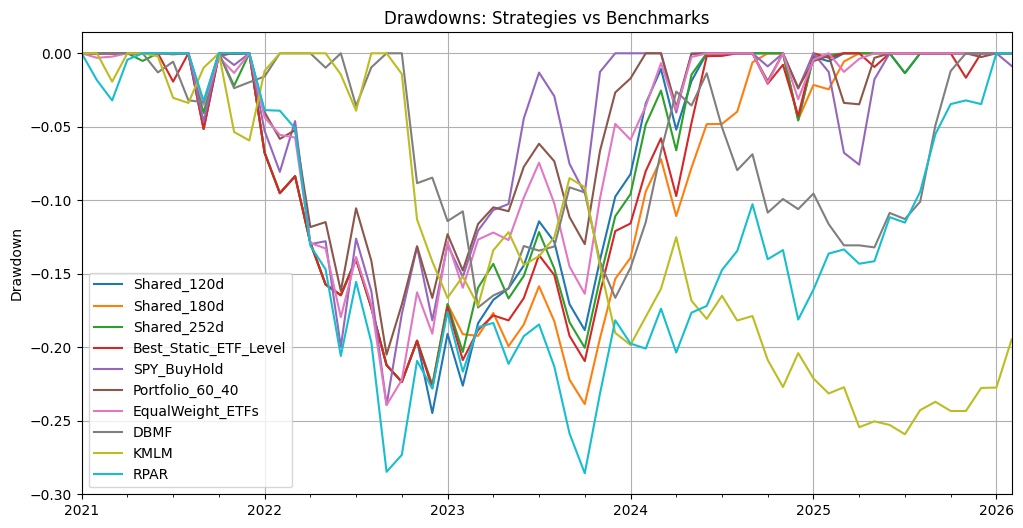

In [13]:
drawdowns = cumulative.div(cumulative.cummax()) - 1

drawdowns.plot(title="Drawdowns: Strategies vs Benchmarks")
plt.ylabel("Drawdown")
plt.show()

## 13. Rolling 3-year Sharpe comparison

In this section, I compare rolling 3-year Sharpe ratios.

## Why this matters

This helps me see whether performance quality is stable through time or concentrated in only one regime.

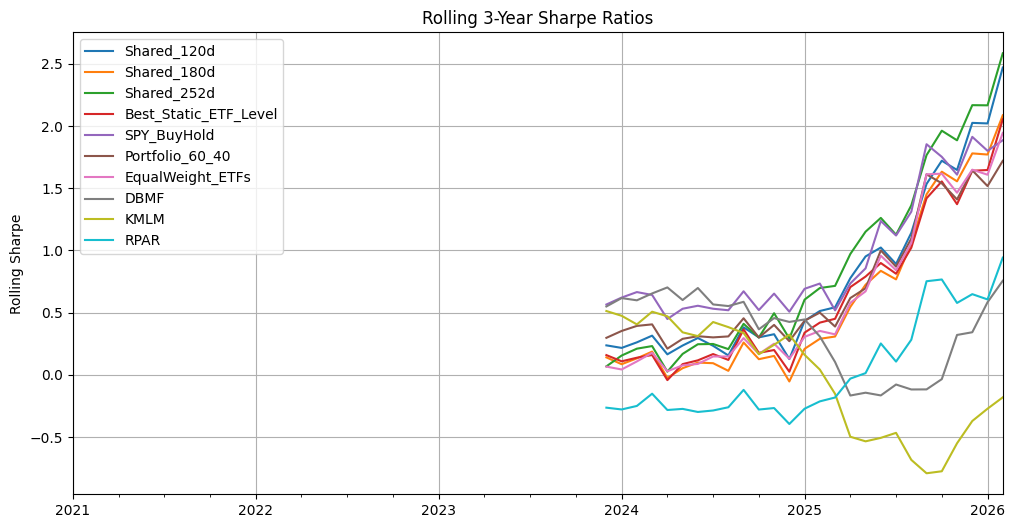

In [14]:
rolling_sharpes = pd.DataFrame(
    {col: rolling_sharpe(all_returns[col], window=36) for col in all_returns.columns}
)

rolling_sharpes.plot(title="Rolling 3-Year Sharpe Ratios")
plt.ylabel("Rolling Sharpe")
plt.show()

## 14. Correlation to SPY

In this section, I measure how correlated each strategy or benchmark is to SPY.

## Why this matters

A professional-style systematic strategy can still be useful even if it does not always have the highest CAGR, especially if it diversifies SPY exposure.

In [15]:
spy_corr = all_returns.corr()["SPY_BuyHold"].sort_values(ascending=False)
spy_corr

SPY_BuyHold              1.000000
Portfolio_60_40          0.971476
EqualWeight_ETFs         0.874935
RPAR                     0.768086
Shared_252d              0.697790
Shared_180d              0.696798
Shared_120d              0.669692
Best_Static_ETF_Level    0.660222
DBMF                    -0.295573
KMLM                    -0.406930
Name: SPY_BuyHold, dtype: float64

## 15. Finalists vs benchmarks summary table

In this section, I create a compact summary table that highlights the most relevant strategies and benchmarks.

## Why this matters

This is the table I would most likely use in the dashboard or project write-up.

In [16]:
summary_names = [
    "Shared_180d",
    "Best_Static_ETF_Level",
    "SPY_BuyHold",
    "Portfolio_60_40",
    "EqualWeight_ETFs",
    "RPAR",
    "DBMF",
    "KMLM",
]

summary_table = metrics_full.loc[summary_names].copy()
summary_table

,CAGR,Annual Vol,Sharpe,Max Drawdown,Calmar
Shared_180d,0.123895,0.120031,1.032194,-0.238701,0.519038
Best_Static_ETF_Level,0.122227,0.126248,0.968148,-0.227819,0.536510
SPY_BuyHold,0.139733,0.149153,0.936839,-0.239272,0.583992
Portfolio_60_40,0.078093,0.108559,0.719360,-0.205075,0.380804
EqualWeight_ETFs,0.083169,0.118623,0.701123,-0.239394,0.347417
RPAR,0.026870,0.136449,0.196921,-0.285808,0.094013
DBMF,0.106964,0.120924,0.884556,-0.172985,0.618344
KMLM,0.043770,0.127912,0.342184,-0.259263,0.168823


## 16. Final recommendation logic

In this section, I make the final recommendation for:
- the main strategy
- the advanced strategy
- which benchmarks matter most

## Why this matters

This notebook is meant to end with a clear decision.

In [17]:
print("Finalist metrics:")
display(finalist_metrics)

main_strategy = "Shared_180d"
advanced_strategy = "Best_Static_ETF_Level"

print("Recommended main strategy:", main_strategy)
print("Recommended advanced strategy:", advanced_strategy)

Finalist metrics:


,CAGR,Annual Vol,Sharpe,Max Drawdown,Calmar
Shared_120d,0.142022,0.127875,1.110625,-0.244820,0.580107
Shared_180d,0.123895,0.120031,1.032194,-0.238701,0.519038
Shared_252d,0.151873,0.131968,1.150828,-0.225921,0.672238
Best_Static_ETF_Level,0.122227,0.126248,0.968148,-0.227819,0.536510


Recommended main strategy: Shared_180d
Recommended advanced strategy: Best_Static_ETF_Level


## 17. Save comparison outputs

In this section, I save the final comparison results for later use in the dashboard/app.

In [18]:
all_returns.to_csv(PROCESSED_DIR / "final_comparison_returns.csv")
metrics_full.to_csv(PROCESSED_DIR / "final_comparison_metrics.csv")
summary_table.to_csv(PROCESSED_DIR / "final_strategy_summary_table.csv")

print("Saved final comparison outputs to:", PROCESSED_DIR.resolve())

Saved final comparison outputs to: /Users/nicholasturangan/Desktop/quant/quant-portfolio-project/data/processed


## 18. Key takeaways from this notebook

At this stage, I have completed the final benchmark comparison across the strongest strategies in the project.

## What I accomplished

- compared the strongest internal strategies against each other
- compared them against simple market benchmarks
- compared them against public professional-style systematic benchmarks
- measured return, risk, drawdown, and correlation behavior
- identified the strongest main strategy and advanced strategy for the app

## What I learned

This notebook shows whether the strategies I built are not only strong within the project, but also competitive against real public baseline portfolios.

## What comes next

The next step is to begin building the dashboard/app that will:
- display these strategies
- show current holdings and recommendations
- compare live and historical performance
- eventually support paper trading and later broker integration